<a href="https://colab.research.google.com/gist/francischisom/6699c14501b76cbcb210b99548af5e07/svm_bert_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM-BERT Hybrid

> Frozen **BERT embeddings** (contextual features) feed a **Support Vector
> Machine** (max-margin decision boundary). This decouples representation
> from classification - fast to train, strong, and well understood.


**Needs a GPU runtime** (torch + transformers).

Dependencies: `svm_bert.py`, `eval_utils.py`, the split CSVs.

## Setup & important installations and importations

In [ ]:
!pip install -q torch transformers numpy pandas scikit-learn matplotlib

In [ ]:
import sys; sys.path.append('.')
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

import eval_utils as ev
import svm_bert as sb
logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
NAVY, RED, GREEN, GRAY = '#00002D', '#C44E52', '#2E8B57', '#4C72B0'
MODEL_KEY = 'svm_bert'      # filenames the integrator looks for
MODEL_TITLE = 'SVM-BERT'

In [ ]:
# Load the leakage-free splits from preprocessing
train_df, val_df, test_df, full_df = ev.load_splits(
    'train.csv', 'val.csv', 'test.csv', 'unified_full.csv')

# uids are the join key the ensemble uses to align everyone's probs
val_df = ev.add_uid(val_df)
test_df = ev.add_uid(test_df)
y_test = test_df[ev.LABEL_COL].values
print('Train', train_df.shape, '| Val', val_df.shape,
      '| Test', test_df.shape)

Train (2156, 8) | Val (470, 9) | Test (451, 9)


##  Train SVM-BERT
`train_and_eval` embeds train + test once with frozen BERT, scales the
features, and fits an RBF-SVM. It returns the test metrics and the fitted
classifier.

In [ ]:
metrics_te, clf = sb.train_and_eval(train_df, test_df)
test_proba = sb.predict_proba_on_df(clf, test_df)
val_proba = sb.predict_proba_on_df(clf, val_df)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


##  Evaluate on the test set

In [ ]:
metrics = ev.compute_metrics(y_test, (test_proba >= 0.5).astype(int),
                             test_proba)
print('Test metrics:', {k: round(v, 4) for k, v in metrics.items()})

Test metrics: {'accuracy': 0.9823, 'precision': 0.9852, 'recall': 0.9852, 'f1': 0.9852, 'f1_macro': 0.9815, 'roc_auc': np.float64(0.9921)}


##  Confusion matrix
The **false negative (missed ADE, bottom-left)** is the costly error in pharmacovigilance.

Missed-ADE (FN) rate: 1.5%


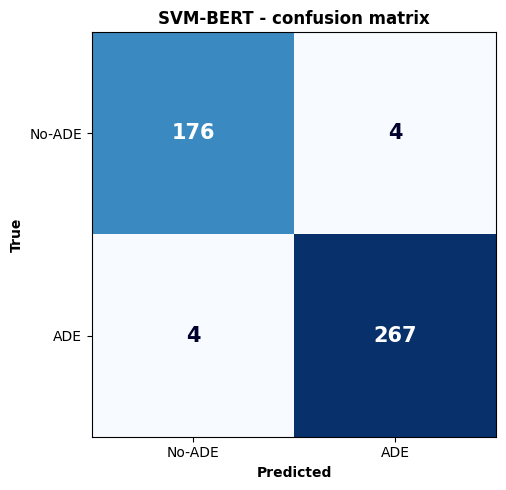

In [ ]:
pred = (test_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['No-ADE', 'ADE'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['No-ADE', 'ADE'])
ax.set_xlabel('Predicted', fontweight='bold')
ax.set_ylabel('True', fontweight='bold')
ax.set_title(f'{MODEL_TITLE} - confusion matrix', fontweight='bold')
thr = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                fontsize=15, fontweight='bold',
                color='white' if cm[i, j] > thr else NAVY)
tn, fp, fn, tp = cm.ravel()
print(f'Missed-ADE (FN) rate: {fn / (fn + tp) if fn + tp else 0:.1%}')
plt.tight_layout(); plt.savefig(f'{MODEL_KEY}_confusion.png', dpi=200)
plt.show()

## ROC curve

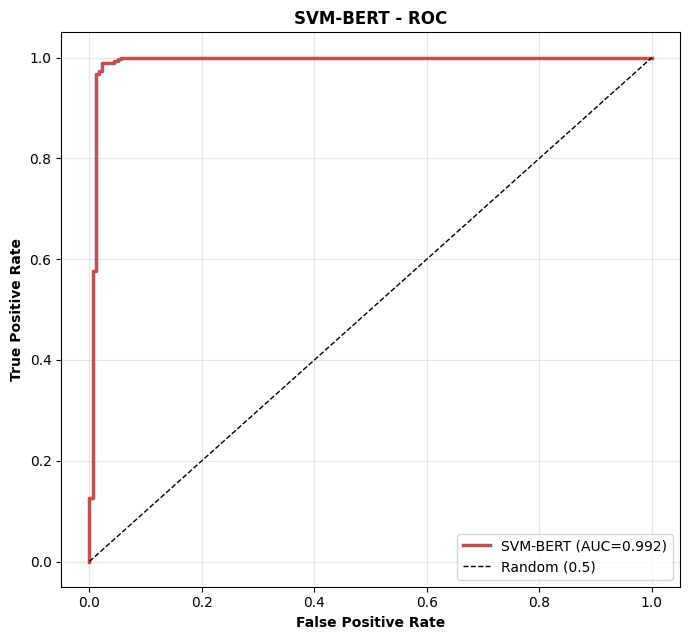

In [ ]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
fig, ax = plt.subplots(figsize=(7, 6.5))
ax.plot(fpr, tpr, lw=2.5, color=RED,
        label=f'{MODEL_TITLE} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title(f'{MODEL_TITLE} - ROC', fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{MODEL_KEY}_roc.png', dpi=200)
plt.show()

##  Probability distribution (decision confidence)
How separable are the two classes under the SVM? Well-separated peaks at
0 and 1 indicate confident, calibrated decisions.

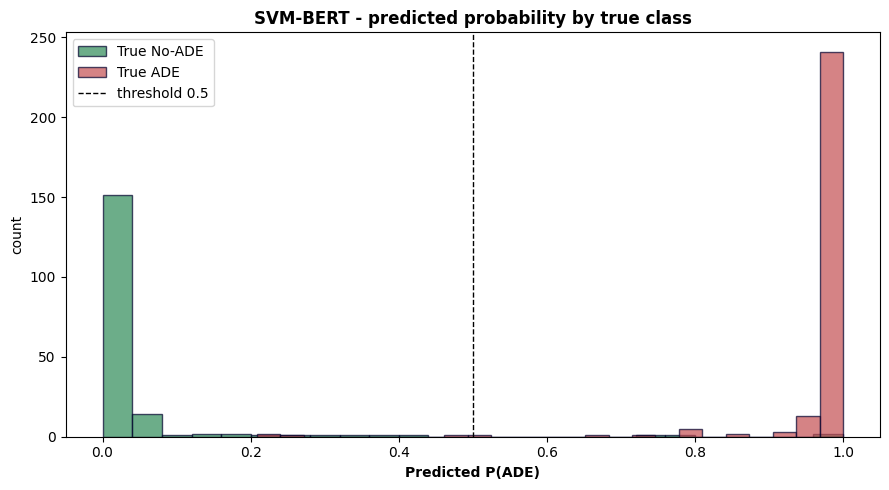

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(test_proba[y_test == 0], bins=25, alpha=0.7, label='True No-ADE',
        color=GREEN, edgecolor=NAVY)
ax.hist(test_proba[y_test == 1], bins=25, alpha=0.7, label='True ADE',
        color=RED, edgecolor=NAVY)
ax.axvline(0.5, color='k', ls='--', lw=1, label='threshold 0.5')
ax.set_xlabel('Predicted P(ADE)', fontweight='bold')
ax.set_ylabel('count'); ax.legend()
ax.set_title('SVM-BERT - predicted probability by true class',
             fontweight='bold')
plt.tight_layout(); plt.savefig('svm_bert_proba_dist.png', dpi=200)
plt.show()

##  Cross-domain preview
Train on Formal, test on Informal - the honest generalisation check.

In [ ]:
cross = sb.run_cross_domain(full_df, 'Formal', 'Informal')
gap = pd.DataFrame([ev.degradation_row(MODEL_TITLE, metrics['f1'],
                                       cross['f1'])])
print(gap.to_string(index=False))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   model  f1_standard  f1_cross  degradation_pct
SVM-BERT       0.9852    0.9943             -0.9


##  Export probabilities for ENSEMBLING


In [ ]:
# Probabilities (uid, label, <model>) - val trains the meta-learner,
# test evaluates it
ev.save_probabilities(val_df, val_proba, MODEL_KEY,
                      f'probs_{MODEL_KEY}_val.csv')
ev.save_probabilities(test_df, test_proba, MODEL_KEY,
                      f'probs_{MODEL_KEY}_test.csv')

# Metrics + cross-domain gap (same schema as the other models)
pd.DataFrame([{'model': MODEL_TITLE, **metrics}]).to_csv(
    f'metrics_{MODEL_KEY}.csv', index=False)
gap.to_csv(f'gap_{MODEL_KEY}.csv', index=False)

print('Exported:',
      f'probs_{MODEL_KEY}_val.csv, probs_{MODEL_KEY}_test.csv,',
      f'metrics_{MODEL_KEY}.csv, gap_{MODEL_KEY}.csv')

Saved 470 probabilities -> probs_svm_bert_val.csv
Saved 451 probabilities -> probs_svm_bert_test.csv
Exported: probs_svm_bert_val.csv, probs_svm_bert_test.csv, metrics_svm_bert.csv, gap_svm_bert.csv


In [ ]:
# Check: confirm the export is ready for ensemble
_chk = pd.read_csv(f'probs_{MODEL_KEY}_test.csv')
assert {'uid', 'label', MODEL_KEY}.issubset(_chk.columns)
print('verified - columns:', list(_chk.columns),
      '| rows:', len(_chk))

Handoff verified - columns: ['uid', 'label', 'svm_bert'] | rows: 451
